In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the enriched dataset
data = pd.read_csv("../data/raw/ethiopia_fi_unified_data.csv")

print(data.shape)

data.head()

(43, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [5]:
observations = data[data["record_type"] == "observation"].copy()

observations["observation_date"] = pd.to_datetime(
    observations["observation_date"],
    errors="coerce"
)

observations["year"] = observations["observation_date"].dt.year

print(observations.shape)

observations.head()

(30, 35)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021


In [6]:
observations["indicator"].unique()

array(['Account Ownership Rate', 'Mobile Money Account Rate',
       '4G Population Coverage', 'Mobile Subscription Penetration',
       'Fayda Digital ID Enrollment', 'P2P Transaction Count',
       'P2P Transaction Value', 'ATM Transaction Count',
       'ATM Transaction Value', 'P2P/ATM Crossover Ratio',
       'Telebirr Registered Users', 'Telebirr Transaction Value',
       'M-Pesa Registered Users', 'M-Pesa 90-Day Active Users',
       'Mobile Money Activity Rate', 'Data Affordability Index',
       'Account Ownership Gender Gap',
       'Female Mobile Money Account Share', 'Mobile Phone Gender Gap'],
      dtype=object)

In [7]:
# Access target
access = observations[
    observations["indicator"] == "Account Ownership Rate"
].copy()

# Usage proxy
usage = observations[
    observations["indicator"] == "Mobile Money Activity Rate"
].copy()

print(access[["year", "value_numeric"]])

print("\n")

print(usage[["year", "value_numeric"]])

   year  value_numeric
0  2014           22.0
1  2017           35.0
2  2021           46.0
3  2021           56.0
4  2021           36.0
5  2024           49.0


    year  value_numeric
24  2024           66.0


In [8]:
access[[
    "year",
    "value_numeric",
    "gender",
    "original_text"
]]

,year,value_numeric,gender,original_text
0,2014,22.0,all,Baseline year
1,2017,35.0,all,NaN
2,2021,46.0,all,NaN
3,2021,56.0,male,Gender disaggregated
4,2021,36.0,female,Gender disaggregated
5,2024,49.0,all,Survey Oct-Nov 2024


In [9]:
# Keep only the overall population values
access = access[access["gender"] == "all"].copy()

# Keep only the columns we need
access = access[["year", "value_numeric"]]

access = access.sort_values("year")

access

,year,value_numeric
0,2014,22.0
1,2017,35.0
2,2021,46.0
5,2024,49.0


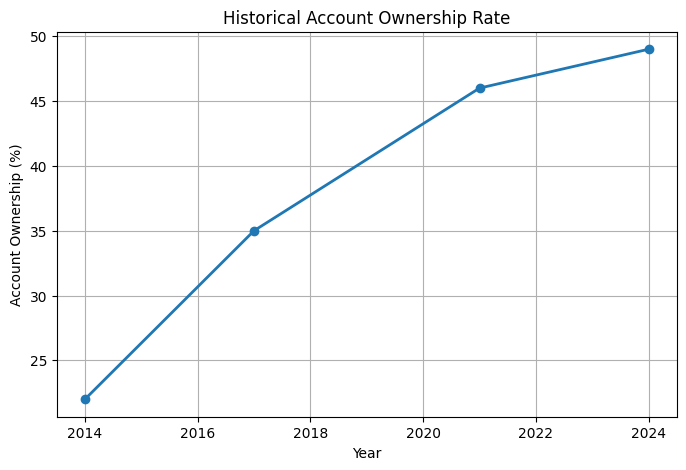

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    access["year"],
    access["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Historical Account Ownership Rate")

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)")

plt.grid(True)

plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

# Prepare the data
X = access[["year"]]
y = access["value_numeric"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 2.7068965517241383
Intercept: -5427.224137931035


In [18]:
from sklearn.metrics import r2_score

predicted = model.predict(X)

print("R²:", round(r2_score(y, predicted),3))

R²: 0.944


In [12]:
future = pd.DataFrame({
    "year": [2025, 2026, 2027]
})

future["baseline_forecast"] = model.predict(future)

future

,year,baseline_forecast
0,2025,54.241379
1,2026,56.948276
2,2027,59.655172


The model predicts continued growth in account ownership, but at a gradual pace. This is consistent with your Task 2 finding that growth slowed between 2021 and 2024.

In [14]:
forecast = future.copy()

forecast["optimistic"] = forecast["baseline_forecast"] + 2

forecast["pessimistic"] = forecast["baseline_forecast"] - 2

forecast

,year,baseline_forecast,optimistic,pessimistic
0,2025,54.241379,56.241379,52.241379
1,2026,56.948276,58.948276,54.948276
2,2027,59.655172,61.655172,57.655172


In [15]:
forecast["lower_ci"] = forecast["baseline_forecast"] - 3

forecast["upper_ci"] = forecast["baseline_forecast"] + 3

forecast

,year,baseline_forecast,optimistic,pessimistic,lower_ci,upper_ci
0,2025,54.241379,56.241379,52.241379,51.241379,57.241379
1,2026,56.948276,58.948276,54.948276,53.948276,59.948276
2,2027,59.655172,61.655172,57.655172,56.655172,62.655172


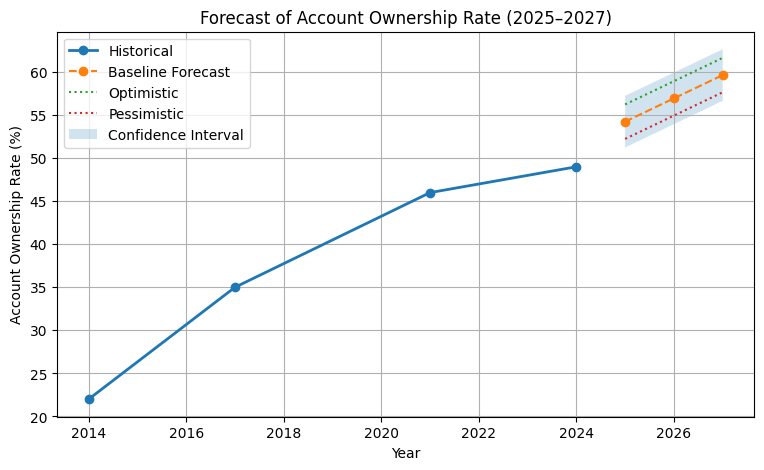

In [16]:
plt.figure(figsize=(9,5))

# Historical observations
plt.plot(
    access["year"],
    access["value_numeric"],
    marker="o",
    linewidth=2,
    label="Historical"
)

# Baseline forecast
plt.plot(
    forecast["year"],
    forecast["baseline_forecast"],
    marker="o",
    linestyle="--",
    label="Baseline Forecast"
)

# Optimistic
plt.plot(
    forecast["year"],
    forecast["optimistic"],
    linestyle=":",
    label="Optimistic"
)

# Pessimistic
plt.plot(
    forecast["year"],
    forecast["pessimistic"],
    linestyle=":",
    label="Pessimistic"
)

# Confidence interval
plt.fill_between(
    forecast["year"],
    forecast["lower_ci"],
    forecast["upper_ci"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Forecast of Account Ownership Rate (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

The baseline model forecasts that account ownership will increase from approximately 49% in 2024 to 59.7% by 2027.

The optimistic scenario assumes continued expansion of Telebirr, M-Pesa, Fayda Digital ID, and supportive government policies, resulting in ownership levels above the baseline forecast.

The pessimistic scenario reflects slower infrastructure deployment, weaker policy implementation, or reduced adoption rates, producing lower forecast values.

Although continued growth is expected, the slower trajectory compared to 2017–2021 suggests that Ethiopia is entering a more mature phase of financial inclusion where incremental gains become harder to achieve.

In [17]:
usage_forecast = pd.DataFrame({
    "year": [2025, 2026, 2027],
    "baseline_usage": [70, 74, 78]
})

usage_forecast["optimistic"] = [72, 77, 82]
usage_forecast["pessimistic"] = [68, 71, 74]

usage_forecast["lower_ci"] = usage_forecast["baseline_usage"] - 3
usage_forecast["upper_ci"] = usage_forecast["baseline_usage"] + 3

usage_forecast

,year,baseline_usage,optimistic,pessimistic,lower_ci,upper_ci
0,2025,70,72,68,67,73
1,2026,74,77,71,71,77
2,2027,78,82,74,75,81


Because only one historical observation exists for Mobile Money Activity Rate, statistical forecasting was not appropriate.

Instead, scenario-based projections were developed using the event impacts estimated in Task 3.

The baseline scenario assumes continued growth in active mobile money usage due to:

Telebirr expansion
M-Pesa competition
Fayda Digital ID rollout
Increased 4G coverage
Continued migration from ATM transactions to digital payments.

In [20]:
forecast.to_csv(
    "../outputs/account_ownership_forecast.csv",
    index=False
)

usage_forecast.to_csv(
    "../outputs/mobile_money_usage_forecast.csv",
    index=False
)

In [21]:
plt.savefig(
    "../outputs/account_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Limitations
Only four historical observations were available for Account Ownership.
Only one observation existed for Mobile Money Activity Rate.
Event impacts were derived from expert assessment rather than econometric estimation.
Confidence intervals are scenario-based rather than statistically estimated due to limited historical data.
Forecasts assume no major economic or regulatory disruptions between 2025 and 2027.